<a href="https://colab.research.google.com/drive/16E2eub4EIc8HfvZIJCVG_qnMqfL2iLaf?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seminar 8 (part 1): Analyze  task-based fMRI for motor and emotion task

**Plan:**

- **Goal.** Use task-based fMRI to link functions ↔ brain regions, and to understand how patterns of activation may relate to impairments (relevant for patient studies).

- **Questions**  we’ll answer in this seminar.

   1. Which regions are engaged by motor tasks?

   2. What’s the difference between left vs. right foot movement?

   3. Which regions respond during face/emotion processing?

   4. What does good experimental design look like (timing, conditions, QC)?

- **Dataset.** We use the Human Connectome Project (HCP): healthy subjects, large open sample, multiple modalities. In this notebook we work with a preprocessed subset: time series parcellated into 360 Glasser parcels (180 per hemisphere).

- **Workflow preview.** Install dependencies → define constants (subjects, parcels, TR) → load data (rest + tasks) → compute functional connectivity (FC) at rest → compute condition contrasts for MOTOR and EMOTION tasks → visualize hemispheric and network-level effects.

## Local setup (Python 3.12 recommended)

### Local installation with Conda

Install Conda by following the official installation guide:

https://docs.conda.io/projects/conda/en/latest/user-guide/install/index.html

Open a terminal in the directory containing this notebook.

Download requirements.txt directly from our [github](https://github.com/BIMAI-lab/NEUROML_course/raw/refs/heads/main/seminar8/requirements.txt) or use this command to download it via terminal:

```bash
curl -L https://github.com/BIMAI-lab/NEUROML_course/raw/refs/heads/main/seminar8/requirements.txt -o requirements.txt # Unix/MacOS
curl.exe -L https://github.com/BIMAI-lab/NEUROML_course/raw/refs/heads/main/seminar8/requirements.txt -o requirements.txt # Win
```

The commands below are the same for macOS, Linux, and Windows. On Windows, use **Anaconda Prompt** or a PowerShell terminal where Conda is available.

### First-time setup

Create a Conda environment with Python 3.12:

```bash
conda create --name fmri-con-seminar python=3.12 pip -y
```

Activate the environment:

```bash
conda activate fmri-con-seminar
```

Install the project dependencies with `pip`:

```bash
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
```

Register the environment as a Jupyter kernel:

```bash
python -m ipykernel install --user \
  --name fmri-con-seminar \
  --display-name "Python (fMRI connectivity seminar)"
```

Start JupyterLab:

```bash
jupyter lab
```

In JupyterLab, open this notebook and select:

**Kernel → Change Kernel → Python (fMRI connectivity seminar)**

#### Subsequent runs

After the initial installation, you only need to activate the environment and start JupyterLab:

```bash
conda activate fmri-con-seminar
jupyter lab
```

#### Updating dependencies

If `requirements.txt` changes, activate the environment and reinstall the dependencies:

```bash
conda activate fmri-con-seminar
python -m pip install -r requirements.txt
```

# 🧭 Data Loading, Preprocessing, and Functional Connectivity

## Orientation: Dataset Setup

### Human Connectome Project (HCP) Dataset loader

The HCP dataset comprises resting-state and task-based fMRI from a large sample of human subjects. The NMA-curated dataset includes time series data that has been preprocessed and spatially-downsampled by aggregating within 360 regions of interest.

In [1]:
# in Colab
!pip install "nilearn==0.10.4" --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 77.1 MB/s eta 0:00:00


In [2]:
import os
import tarfile
import requests
from tqdm import tqdm
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Necessary for visualization
from nilearn import plotting, datasets

In [3]:
#@title Figure settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/master/nma.mplstyle")

In [4]:
# The download cells will store the data in nested directories starting here:
HCP_DIR = "./data_seminar_fmri_part1"
if not os.path.isdir(HCP_DIR):
  os.mkdir(HCP_DIR)

# The data shared for NMA projects is a subset of the full HCP dataset
N_SUBJECTS = 339

# The data have already been aggregated into ROIs from the Glasser parcellation
N_PARCELS = 360

# The acquisition parameters for all tasks were identical
TR = 0.72  # Time resolution, in sec

# The parcels are matched across hemispheres with the same order
HEMIS = ["Right", "Left"]

# Each experiment was repeated multiple times in each subject
N_RUNS_REST = 4
N_RUNS_TASK = 2

# Time series data are organized by experiment, with each experiment
# having an LR and RL (phase-encode direction) acquistion
BOLD_NAMES = [
  "rfMRI_REST1_LR", "rfMRI_REST1_RL",
  "rfMRI_REST2_LR", "rfMRI_REST2_RL",
  "tfMRI_MOTOR_RL", "tfMRI_MOTOR_LR",
  "tfMRI_WM_RL", "tfMRI_WM_LR",
  "tfMRI_EMOTION_RL", "tfMRI_EMOTION_LR",
  "tfMRI_GAMBLING_RL", "tfMRI_GAMBLING_LR",
  "tfMRI_LANGUAGE_RL", "tfMRI_LANGUAGE_LR",
  "tfMRI_RELATIONAL_RL", "tfMRI_RELATIONAL_LR",
  "tfMRI_SOCIAL_RL", "tfMRI_SOCIAL_LR"
]

# You may want to limit the subjects used during code development.
# This will use all subjects:
subjects = range(N_SUBJECTS)

**Where data live and how they are organized**

- 📂 HCP_DIR — our working folder. All data (rest, tasks, events, parcellation) will be downloaded here.

- 👥 N_SUBJECTS = 339 — number of participants in our subset of HCP. Loops will iterate over these subjects.
- 🧩 N_PARCELS = 360 — Glasser atlas parcels (instead of voxels). Each fMRI run → matrix 360 × T.
- ⏱ TR = 0.72 sec — time per frame. Needed to convert event timings (onset/duration) into frames and to model HRF delay (~5 TR).
- 🧠 HEMIS = [“Right”, “Left”] — parcel order matches hemispheres: first right, then left. Makes it easy to split contrasts into hemispheres.
- 🔁 N_RUNS_REST = 4, N_RUNS_TASK = 2 — number of runs for rest and for each task. Helps when concatenating runs.
- 🎞 BOLD_NAMES = […] — names of all acquisitions. Each task has 2 runs: LR and RL phase-encode directions. Helper functions use this list to find the correct runs.
- 🔢 subjects = range(N_SUBJECTS) — indices of all participants.

## Downloading data

The resting‐state and task fMRI data are provided as separate archive files, but once unpacked they share the same directory structure.

Each archive is fairly large and may take some time to download. If your analysis is focused only on resting state or task fMRI, you can choose to download just the corresponding dataset.

We also provide a separate archive with behavioral covariates that may be useful for complementary analyses.


The code below programmatically downloads these archives from the OSF (Open Science Framework). Before downloading, it checks whether the file already exists locally. If it does, the download is skipped; otherwise, the file is fetched and saved into the working directory. As a result, you will have three large archives (rest, task, covariates) and one additional file with the atlas.

In [5]:
# @title Download the data

# @markdown Task data in `HCP_DIR/hcp_task`, rest in `HCP_DIR/hcp_rest`, covariate in `HCP_DIR/hcp`

files = {
    "hcp_rest.tgz": "https://cloud.appliedai.tech/s/6wXEsjEiJJLRyyA/download?path=%2FSeminar%208&files=hcp_rest.tgz",
    "hcp_task.tgz": "https://cloud.appliedai.tech/s/6wXEsjEiJJLRyyA/download?path=%2FSeminar%208&files=hcp_task.tgz",
    "hcp_covariates.tgz": "https://cloud.appliedai.tech/s/6wXEsjEiJJLRyyA/download?path=%2FSeminar%208&files=hcp_covariates.tgz",
    "atlas.npz": "https://cloud.appliedai.tech/s/6wXEsjEiJJLRyyA/download?path=%2FSeminar%208&files=atlas.npz",
}

for fname, url in files.items():
    if os.path.exists(fname):
        continue

    try:
        with requests.get(url, stream=True) as r:
            r.raise_for_status()
            total = int(r.headers.get("content-length", 0))

            with open(fname, "wb") as f, tqdm(
                total=total,
                desc=fname,
                unit="B",
                unit_scale=True,
                unit_divisor=1024,
            ) as bar:
                for chunk in r.iter_content(1024 * 1024):
                    f.write(chunk)
                    bar.update(len(chunk))

        print(f"Downloaded {fname}")

    except requests.RequestException as e:
        print(f"Failed to download {fname}: {e}")

hcp_rest.tgz: 100%|██████████| 1.52G/1.52G [02:41<00:00, 10.1MB/s]


Downloaded hcp_rest.tgz


hcp_task.tgz: 100%|██████████| 1.27G/1.27G [01:54<00:00, 11.9MB/s]


Downloaded hcp_task.tgz


hcp_covariates.tgz: 100%|██████████| 837k/837k [00:00<00:00, 1.03MB/s]


Downloaded hcp_covariates.tgz


atlas.npz: 100%|██████████| 89.2k/89.2k [00:00<00:00, 327kB/s]

Downloaded atlas.npz


## Extracting the data
In the next step, we unpack the three archives (rest, task, covariates) into the working folder HCP_DIR. The code checks whether the corresponding directories already exist. If they do, extraction is skipped; if not, the archives are unpacked.

After this step, the working directory HCP_DIR contains three subfolders:
- hcp_rest – resting-state fMRI,
- hcp_task – task-based fMRI,
- hcp_covariates – behavioral covariates.

Each of these folders stores the data for individual subjects along with the associated event files and supporting information.

In [6]:
# @title Extract the data in `HCP_DIR`

HCP_DIR = Path(HCP_DIR)

for fname in ("hcp_covariates", "hcp_rest", "hcp_task"):
    target = HCP_DIR / fname

    if target.exists():
        print(f"{fname}.tgz already extracted.")
        continue

    print(f"Extracting {fname}.tgz...")
    with tarfile.open(f"{fname}.tgz") as tar:
        members = tar.getmembers()
        tar.extractall(
            HCP_DIR,
            members=tqdm(members, desc=fname, unit="file")
        )

Extracting hcp_covariates.tgz...


hcp_covariates:   0%|          | 0/19018 [00:00<?, ?file/s]/tmp/ipykernel_1778/723465632.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(
hcp_covariates: 100%|██████████| 19018/19018 [00:01<00:00, 10741.63file/s]


Extracting hcp_rest.tgz...


hcp_rest: 100%|██████████| 3409/3409 [00:53<00:00, 63.20file/s]


Extracting hcp_task.tgz...


hcp_task: 100%|██████████| 87500/87500 [00:56<00:00, 1540.15file/s]


## Loading region information

Downloading either dataset will create the `regions.npy` file, which contains the region name and network assignment for each parcel.

This file contains:

- Region name (e.g., V1, Area 4, MT),
- Network assignment (e.g., Visual, Somatomotor, Default Mode).

With this file you can:

- Map each row of your 360 × T time-series to a specific anatomical parcel,
- Aggregate results not only by ROI but also by larger functional networks.

Detailed information about the name used for each region is provided [in the Supplement](https://static-content.springer.com/esm/art%3A10.1038%2Fnature18933/MediaObjects/41586_2016_BFnature18933_MOESM330_ESM.pdf) to [Glasser et al. 2016](https://www.nature.com/articles/nature18933).

Information about the network parcellation is provided in [Ji et al, 2019](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6289683/).

In [7]:
dir = os.path.join(HCP_DIR, "hcp_task")  # choose the data directory
regions = np.load(os.path.join(dir, "regions.npy")).T
region_info = dict(name=regions[0].tolist(),
                   network=regions[1],
                   myelin=regions[2].astype(float)
                   )

In [8]:
region_info

{'name': ['R_V1',
  'R_MST',
  'R_V6',
  'R_V2',
  'R_V3',
  'R_V4',
  'R_V8',
  'R_4',
  'R_3b',
  'R_FEF',
  'R_PEF',
  'R_55b',
  'R_V3A',
  'R_RSC',
  'R_POS2',
  'R_V7',
  'R_IPS1',
  'R_FFC',
  'R_V3B',
  'R_LO1',
  'R_LO2',
  'R_PIT',
  'R_MT',
  'R_A1',
  'R_PSL',
  'R_SFL',
  'R_PCV',
  'R_STV',
  'R_7Pm',
  'R_7m',
  'R_POS1',
  'R_23d',
  'R_v23ab',
  'R_d23ab',
  'R_31pv',
  'R_5m',
  'R_5mv',
  'R_23c',
  'R_5L',
  'R_24dd',
  'R_24dv',
  'R_7AL',
  'R_SCEF',
  'R_6ma',
  'R_7Am',
  'R_7PL',
  'R_7PC',
  'R_LIPv',
  'R_VIP',
  'R_MIP',
  'R_1',
  'R_2',
  'R_3a',
  'R_6d',
  'R_6mp',
  'R_6v',
  'R_p24pr',
  'R_33pr',
  'R_a24pr',
  'R_p32pr',
  'R_a24',
  'R_d32',
  'R_8BM',
  'R_p32',
  'R_10r',
  'R_47m',
  'R_8Av',
  'R_8Ad',
  'R_9m',
  'R_8BL',
  'R_9p',
  'R_10d',
  'R_8C',
  'R_44',
  'R_45',
  'R_47l',
  'R_a47r',
  'R_6r',
  'R_IFJa',
  'R_IFJp',
  'R_IFSp',
  'R_IFSa',
  'R_p9-46v',
  'R_46',
  'R_a9-46v',
  'R_9-46d',
  'R_9a',
  'R_10v',
  'R_a10p',
  'R_10pp'

<details>
<summary><strong>Reflection: What is region_info?</strong></summary>

`region_info` is a Python dictionary loaded from **regions.npy**.  
It contains metadata for each of the 360 parcels in the Glasser atlas.  
Typically, it has three keys:

- **'name'** – list of region names  
  - Example: `R_V1`, `R_MST`, `R_V6`, …  
  - Prefix `R_` = Right hemisphere, `L_` = Left hemisphere.  
  - For example:  
    - `R_V1` → right primary visual cortex  
    - `R_4` → right primary motor cortex (Area 4)  
    - `R_FEF` → frontal eye fields  

- **'network'** – functional network assignment for each region  
  - Examples: *Visual, Somatomotor, Dorsal Attention, Default Mode*, etc.  
  - Useful for summarizing results not only by individual ROI but also by whole networks.  

- **'myelin'** – numerical values (floats), e.g. 1.72, 1.69, 1.89, …  
  - Represents the myelin map for each region (from HCP).  
  - Higher values → higher cortical myelination (often in sensory and motor areas).  

👉 **In short:** `region_info` is the lookup table that lets us interpret ROI indices (by name), group them into networks, and optionally use myelin values as extra biological information.
</details>

We also provide the [parcellation on the fsaverage5 surface](https://figshare.com/articles/HCP-MMP1_0_projected_on_fsaverage/3498446) and approximate MNI coordinates of each region, which can be useful for visualization:

<details>
<summary><strong>Reflection: What is parcellation?</strong></summary>

👉 **Parcellation** means dividing the cortex into distinct regions (*parcels*),  
each assumed to have relatively homogeneous structure and function.  

In the **Glasser atlas**, the cortex is split into **360 parcels** (180 per hemisphere).  
Each parcel can then be treated as a single “unit” for analysis, instead of working voxel by voxel.
</details>

In [9]:
with np.load(f"atlas.npz") as dobj:
  atlas = dict(**dobj)

In [10]:
atlas.keys()

dict_keys(['labels_R', 'labels_L', 'coords'])

<details>
<summary><strong>Reflection: What is atlas.npz?</strong></summary>

The file **atlas.npz** stores additional resources for visualization.  
It complements `regions.npy` (which contains region names, networks, and myelin values) with surface maps and coordinates.

It contains three keys:

- **`labels_R`** – parcellation map of the **right hemisphere** on the *fsaverage5* cortical surface (from FreeSurfer).  
- **`labels_L`** – parcellation map of the **left hemisphere** on the *fsaverage5* surface.  
- **`coords`** – approximate **MNI coordinates** (x, y, z) of each parcel’s centroid.  

📌 These data are especially useful for visualization:  
- You can project contrasts or network values directly onto the cortical surface.  
- You can also build connectome diagrams in MNI space using the parcel coordinates.  

👉 **In short:** `atlas.npz` provides the tools to move from raw matrices to interpretable brain images — coloring parcels on the surface or plotting ROI-to-ROI connections in 3D space.
</details>

## 🔧 Helper functions for loading HCP data


### Data loading

Before we can analyze the tasks, we need functions that bridge the raw data files with our analysis workflow.
- Each subject’s fMRI runs are stored as .npy matrices (360 parcels × timepoints).
- Each task also comes with EV files (explanatory variables) describing when each condition happened (onset, duration, amplitude).
- Runs are organized with unique IDs in BOLD_NAMES.

To avoid writing repetitive code every time, we define a few helper functions:

 1. get_image_ids(name) – find the run indices (1-based) for a given experiment ("rest", "MOTOR", "EMOTION", etc.).

 2. load_single_timeseries(subject, bold_run, dir) – load one subject’s fMRI time series for a single run.
 3. load_timeseries(subject, name, dir, …) – load all runs of a task for one subject, with options to concatenate them and to remove the parcel-wise mean.
 4. load_evs(subject, name, condition, dir) – load the EV files for a given subject, task, and condition (e.g., "fear", "neut", "lf", "rf").


👉 Together, these functions let us:

- Quickly fetch the correct time series,

- Organize data by runs and conditions,
- Align BOLD activity with the experimental design.

In [11]:
def get_image_ids(name):
  """Get the 1-based image indices for runs in a given experiment.

    Args:
      name (str) : Name of experiment ("rest" or name of task) to load
    Returns:
      run_ids (list of int) : Numeric ID for experiment image files

  """
  run_ids = [
             i for i, code in enumerate(BOLD_NAMES, 1) if name.upper() in code
             ]
  if not run_ids:
    raise ValueError(f"Found no data for '{name}'")
  return run_ids


def load_timeseries(subject, name, dir,
                    runs=None, concat=True, remove_mean=True):
  """Load timeseries data for a single subject.

  Args:
    subject (int): 0-based subject ID to load
    name (str) : Name of experiment ("rest" or name of task) to load
    dir (str) : data directory
    run (None or int or list of ints): 0-based run(s) of the task to load,
      or None to load all runs.
    concat (bool) : If True, concatenate multiple runs in time
    remove_mean (bool) : If True, subtract the parcel-wise mean

  Returns
    ts (n_parcel x n_tp array): Array of BOLD data values

  """
  # Get the list relative 0-based index of runs to use
  if runs is None:
    runs = range(N_RUNS_REST) if name == "rest" else range(N_RUNS_TASK)
  elif isinstance(runs, int):
    runs = [runs]
  # Get the first (1-based) run id for this experiment
  offset = get_image_ids(name)[0]

  # Load each run's data
  bold_data = [
               load_single_timeseries(subject,
                                      offset + run,
                                      dir,
                                      remove_mean) for run in runs
               ]

  # Optionally concatenate in time
  if concat:
    bold_data = np.concatenate(bold_data, axis=-1)

  return bold_data


def load_single_timeseries(subject, bold_run, dir, remove_mean=True):
  """Load timeseries data for a single subject and single run.

  Args:
    subject (int): 0-based subject ID to load
    bold_run (int): 1-based run index, across all tasks
    dir (str) : data directory
    remove_mean (bool): If True, subtract the parcel-wise mean

  Returns
    ts (n_parcel x n_timepoint array): Array of BOLD data values

  """
  bold_path = os.path.join(dir, "subjects", str(subject), "timeseries")
  bold_file = f"bold{bold_run}_Atlas_MSMAll_Glasser360Cortical.npy"
  ts = np.load(os.path.join(bold_path, bold_file))
  if remove_mean:
    ts -= ts.mean(axis=1, keepdims=True)
  return ts


def load_evs(subject, name, condition, dir):
  """Load EV (explanatory variable) data for one task condition.

  Args:
    subject (int): 0-based subject ID to load
    name (str) : Name of task
    condition (str) : Name of condition
    dir (str) : data directory

  Returns
    evs (list of dicts): A dictionary with the onset, duration, and amplitude
      of the condition for each run.

  """
  evs = []
  for id in get_image_ids(name):
    task_key = BOLD_NAMES[id - 1]
    ev_file = os.path.join(dir, "subjects", str(subject), "EVs",
                           task_key, f"{condition}.txt")
    ev_array = np.loadtxt(ev_file, ndmin=2, unpack=True)
    ev = dict(zip(["onset", "duration", "amplitude"], ev_array))
    evs.append(ev)
  return evs

### Task-based analysis

So far, we can load time series for each subject and task, and we can read EV files describing when each condition occurs (e.g., "fear", "neutral", "left foot").
But to compare brain activity between conditions, we need to extract only the frames that correspond to each condition and then average them.

To do this, we define two helper functions:
 1. condition_frames(run_evs, skip=0)

 -  Converts onset/duration information into frame indices.

 -  skip lets us ignore a few initial frames of each trial to account for the hemodynamic delay (BOLD signal lags by ~5s).

 -  Output: for each run, a list of frame numbers that belong to the chosen condition.

 2. selective_average(timeseries_data, ev, skip=0)

 -  Uses condition_frames to pick out the relevant frames from the time series.


 -  Then averages the BOLD activity across those frames for each parcel.

 -  Output: a 1D vector (length = number of parcels), representing the mean activation map for that condition.

👉 In short, these functions let us move from:

 a. raw fMRI signals (all frames) + event timings → b. condition-specific activation profiles (one vector per condition).

This is the critical step that makes it possible to compute contrasts (e.g., left finger vs. right finger, fear vs. neutral).

In [12]:
def condition_frames(run_evs, skip=0):
  """Identify timepoints corresponding to a given condition in each run.

  Args:
    run_evs (list of dicts) : Onset and duration of the event, per run
    skip (int) : Ignore this many frames at the start of each trial, to account
      for hemodynamic lag

  Returns:
    frames_list (list of 1D arrays): Flat arrays of frame indices, per run

  """
  frames_list = []
  for ev in run_evs:

    # Determine when trial starts, rounded down
    start = np.floor(ev["onset"] / TR).astype(int)

    # Use trial duration to determine how many frames to include for trial
    duration = np.ceil(ev["duration"] / TR).astype(int)

    # Take the range of frames that correspond to this specific trial
    frames = [s + np.arange(skip, d) for s, d in zip(start, duration)]

    frames_list.append(np.concatenate(frames))

  return frames_list


def selective_average(timeseries_data, ev, skip=0):
  """Take the temporal mean across frames for a given condition.

  Args:
    timeseries_data (array or list of arrays): n_parcel x n_tp arrays
    ev (dict or list of dicts): Condition timing information
    skip (int) : Ignore this many frames at the start of each trial, to account
      for hemodynamic lag

  Returns:
    avg_data (1D array): Data averagted across selected image frames based
    on condition timing

  """
  # Ensure that we have lists of the same length
  if not isinstance(timeseries_data, list):
    timeseries_data = [timeseries_data]
  if not isinstance(ev, list):
    ev = [ev]
  if len(timeseries_data) != len(ev):
    raise ValueError("Length of `timeseries_data` and `ev` must match.")

  # Identify the indices of relevant frames
  frames = condition_frames(ev, skip)

  # Select the frames from each image
  selected_data = []
  for run_data, run_frames in zip(timeseries_data, frames):
    run_frames = run_frames[run_frames < run_data.shape[1]]
    selected_data.append(run_data[:, run_frames])

  # Take the average in each parcel
  avg_data = np.concatenate(selected_data, axis=-1).mean(axis=-1)

  return avg_data

### Resting-state analyses

Load a single run of resting-state data:

In [17]:
help(load_timeseries)

Help on function load_timeseries in module __main__:

load_timeseries(subject, name, dir, runs=None, concat=True, remove_mean=True)
    Load timeseries data for a single subject.

    Args:
      subject (int): 0-based subject ID to load
      name (str) : Name of experiment ("rest" or name of task) to load
      dir (str) : data directory
      run (None or int or list of ints): 0-based run(s) of the task to load,
        or None to load all runs.
      concat (bool) : If True, concatenate multiple runs in time
      remove_mean (bool) : If True, subtract the parcel-wise mean

    Returns
      ts (n_parcel x n_tp array): Array of BOLD data values



Prints the docstring of load_timeseries: what arguments it takes (subject, experiment name, data dir, which runs, whether to concatenate, whether to remove parcel-wise mean) and what it returns (n_parcel × n_timepoint array).

In [13]:
get_image_ids(name="rest")

[1, 2, 3, 4]

- Looks up 1-based run IDs for the REST experiment in BOLD_NAMES.

- REST has four runs (REST1_LR, REST1_RL, REST2_LR, REST2_RL).

In [19]:
get_image_ids(name="LANGUAGE")


[13, 14]

Finds the two LANGUAGE runs (LR/RL) in BOLD_NAMES.

In [20]:
get_image_ids(name="MOTOR")

[5, 6]

Finds the two MOTOR runs (LR/RL) in BOLD_NAMES.

In [22]:
timeseries = load_timeseries(subject=0,
                             name="rest",
                             dir=os.path.join(HCP_DIR, "hcp_rest"),
                             runs=1)
print(timeseries.shape)  # n_parcel x n_timepoint

(360, 1200)


- runs=1 means: use the second REST run (runs are 0-based inside this helper; it adds an offset from get_image_ids under the hood).

- Returns a matrix 360 × 1200: 360 Glasser parcels by 1200 timepoints for that run (TR=0.72 s).

Load a concatenated resting-state timeseries (using all runs' data) for each subject:

In [14]:
timeseries_rest = []
for subject in tqdm(subjects, total=len(subjects), desc="Concatenating..."):
  ts_concat = load_timeseries(subject, name="rest",
                              dir=os.path.join(HCP_DIR, "hcp_rest"))
  timeseries_rest.append(ts_concat)

Concatenating...: 100%|██████████| 339/339 [00:34<00:00,  9.75it/s]


-  Default runs=None (and concat=True) → loads all 4 REST runs for each subject and concatenates them along time.
-  For HCP REST, that typically yields 360 × 4800 per subject (4 × 1200 timepoints).
-  timeseries_rest becomes a list with one concatenated array per subject (length = number of subjects you set earlier).

### Run a simple correlation-based "functional connectivity" analysis

Transform resting-state time series into subject-level correlation matrices, averaged them across subjects, and visualized the group-level functional connectivity structure (FC) of the brain.

<details>
<summary><strong>Step by step</strong></summary>

1. <strong>Built subject-level correlation matrices</strong>  
   - For each subject, we took their concatenated resting-state time series (<code>360 × timepoints</code>).  
   - We computed the Pearson correlation between every pair of parcels (<code>np.corrcoef(ts)</code>), giving a <code>360 × 360</code> matrix per subject.  
   - This matrix shows how strongly the activity of two regions co-fluctuates during rest.

2. <strong>Stacked across subjects</strong>  
   - We stored all subject matrices into one array <code>fc</code> of shape <code>(N_SUBJECTS, 360, 360)</code>.

3. <strong>Computed the group average</strong>  
   - By averaging across subjects (<code>fc.mean(axis=0)</code>), we obtained a group-level functional connectivity (FC) matrix.

4. <strong>Plotted the group FC</strong>  
   - Each pixel = mean correlation between two regions across all subjects.  
   - <strong>Red</strong> = positive correlation (regions co-activate),  
   - <strong>Blue</strong> = negative correlation (anti-correlated activity),  
   - <strong>White ≈ 0</strong> = weak or no relationship.
</details>

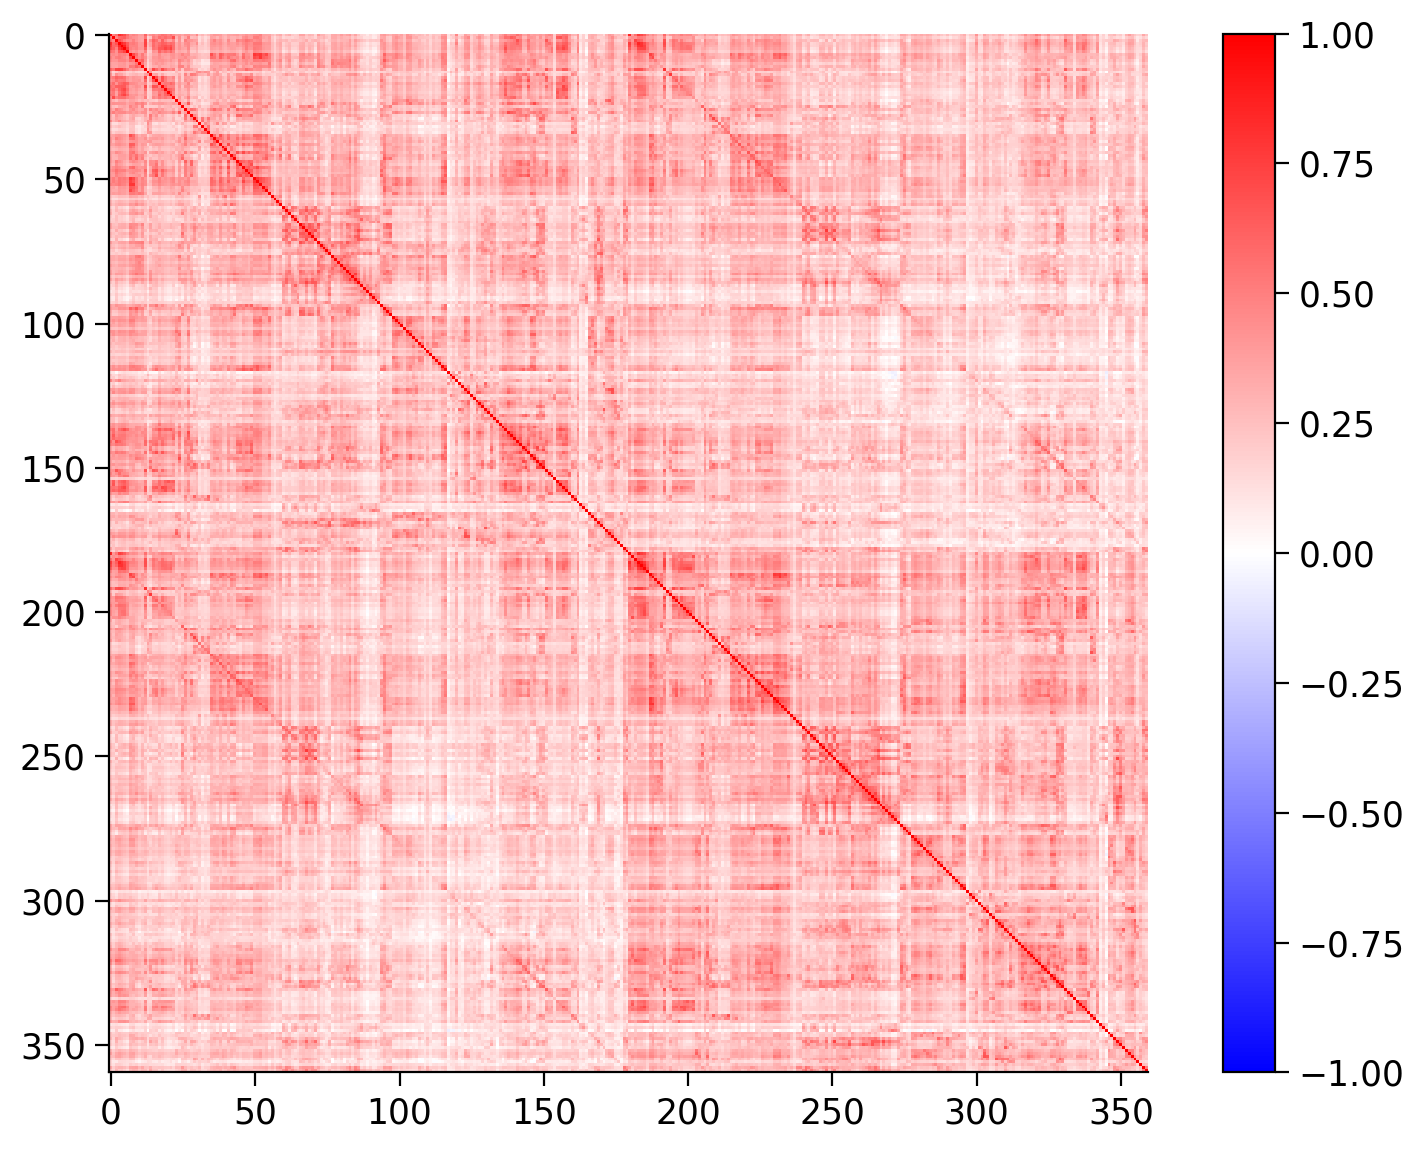

In [26]:
fc = np.zeros((N_SUBJECTS, N_PARCELS, N_PARCELS))
for sub, ts in enumerate(timeseries_rest):
  fc[sub] = np.corrcoef(ts)

group_fc = fc.mean(axis=0)

plt.figure()
plt.imshow(group_fc, interpolation="none", cmap="bwr", vmin=-1, vmax=1)
plt.colorbar()
plt.show()

<details>
<summary><strong>Reflection: What we obtained?</strong></summary>

- The result is a **360 × 360 symmetric matrix**, where the diagonal is always 1 (each region perfectly correlates with itself), and the off-diagonal entries show the strength of connections between different parcels.  
- The dominance of red indicates that most ROI pairs are positively correlated — brain regions tend to co-fluctuate during rest, which is expected in resting-state fMRI.  
- Clear **block-like structures along the diagonal** correspond to functional networks (e.g., visual, somatomotor, default mode), where regions within the same network are more strongly correlated.  
- White areas represent near-zero correlations (weak connections).  
- Because this is averaged across all subjects, individual noise is reduced and the **stable network organization of the resting brain** emerges. These block patterns are the hallmark of resting-state fMRI and underpin the mapping of intrinsic functional networks.  

👉 **In short:** the matrix reveals the brain’s network architecture at rest — strong within-network synchrony.
</details>

Plot the profile of FC values between a particular "seed" parcel and every parcel in the dataset, separated by hemisphere:

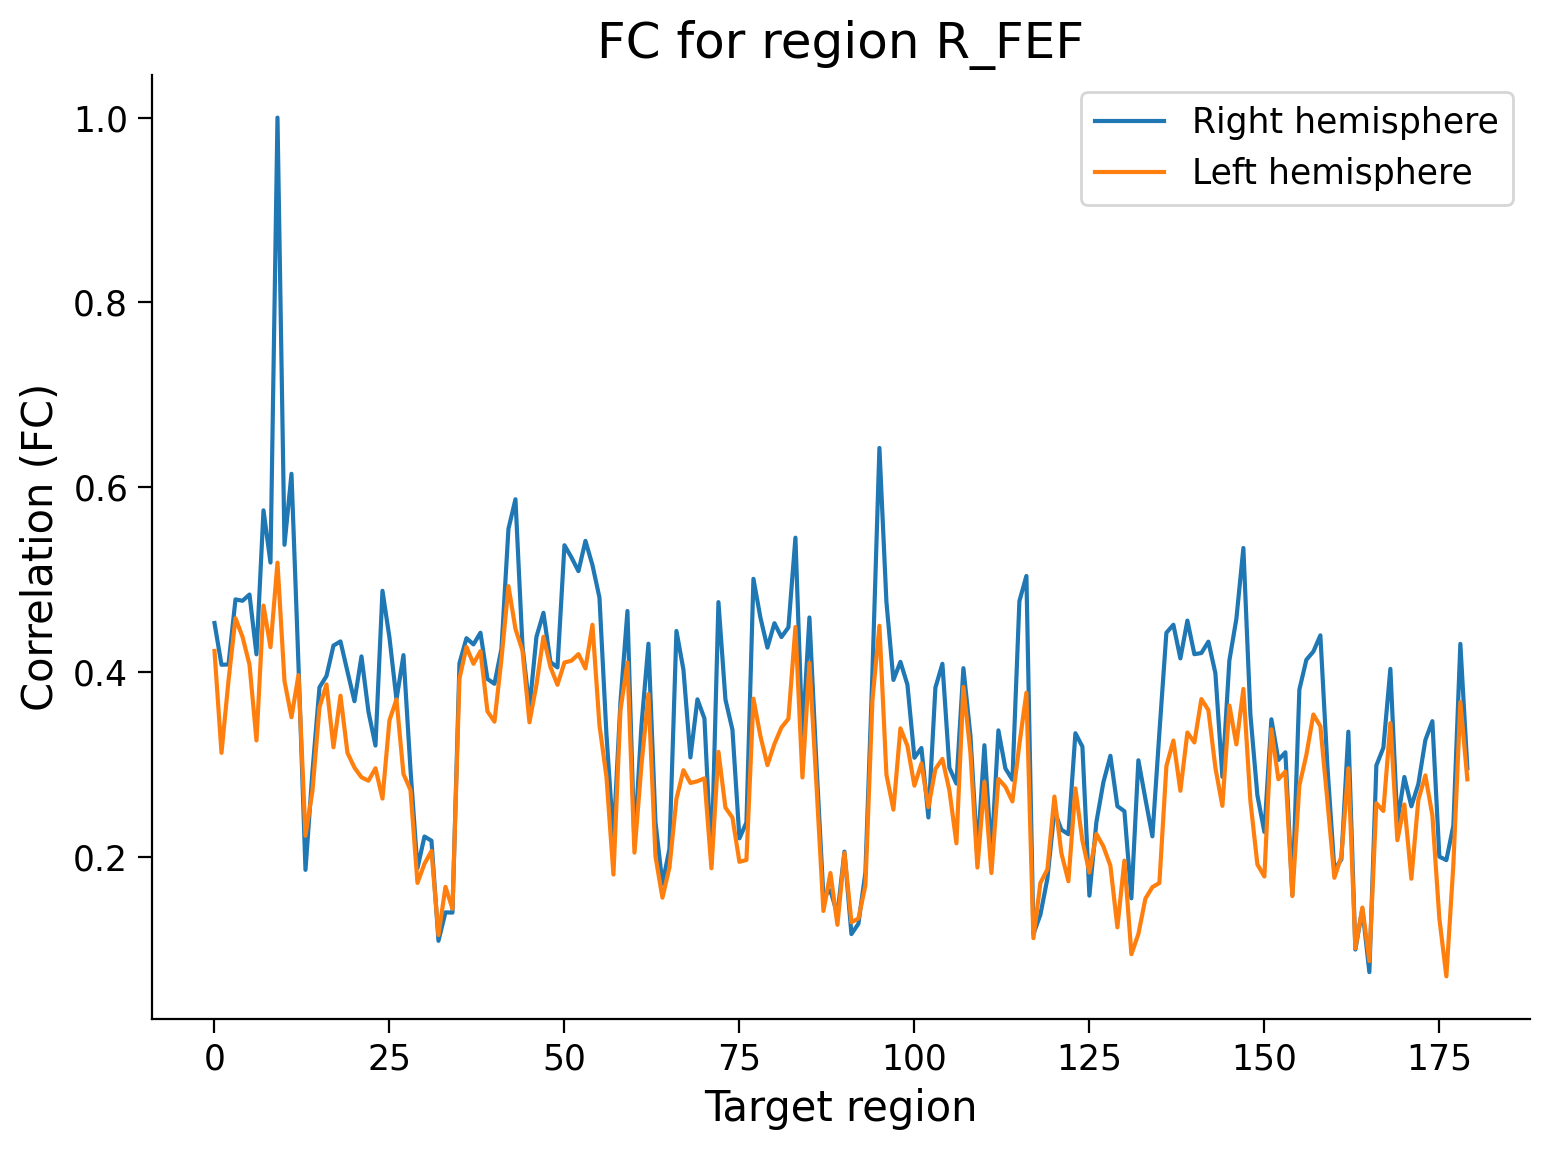

In [29]:
seed_roi = "R_FEF"  # We pick one parcel of interest (R_FEF = right frontal eye field).
ind = region_info["name"].index(seed_roi) # Find its index in the list of all 360 parcels.

hemi_fc = np.split(group_fc, 2) # The group functional connectivity matrix (group_fc) is 360 × 360. We split it into two halves: the first 180 parcels (right hemisphere) and the second 180 (left hemisphere). This allows us to plot FC values separately for right and left targets.

# Plot the FC profile across the right and left hemisphere target regions
plt.figure()
for i, hemi_fc in enumerate(hemi_fc): # For each hemisphere, we take the column corresponding to the seed index → correlations between the seed parcel and all parcels in that hemisphere.
  plt.plot(hemi_fc[:, ind], label=f"{HEMIS[i]} hemisphere")
plt.title(f"FC for region {seed_roi}")
plt.xlabel("Target region")
plt.ylabel("Correlation (FC)")
plt.legend()
plt.show()

<details>
<summary><strong>Reflection: 🔎 How to interpret the graph?</strong></summary>

- **X-axis (Target region)**  
  - Each tick corresponds to one parcel (ROI) in the brain atlas (0–179 per hemisphere).  
  - It’s essentially the “list of brain regions” we are comparing against the seed.  

- **Y-axis (Correlation / FC)**  
  - Shows the strength of functional connectivity (Pearson correlation) between the seed region (**R_FEF**, the right frontal eye field) and each target parcel.  
  - Values range from 0 up to ~1 here (strong positive correlation).  

- **Two curves**  
  - **Blue** = connectivity profile of R_FEF with all parcels in the **right hemisphere**.  
  - **Orange** = connectivity profile of R_FEF with all parcels in the **left hemisphere**.  
  - Where the blue curve is higher → stronger intra-hemispheric connections.  
  - Where both overlap → symmetric connectivity across hemispheres.  

- **Peaks**  
  - Sharp rises in the curve indicate regions that are most strongly coupled with R_FEF.  
  - These likely correspond to other areas involved in **eye movement and visuospatial attention** (e.g., intraparietal sulcus, supplementary eye field, visual cortex).  
</details>

The next step turns the dense correlation matrix into a **brain network visualization**, highlighting only the most robust connections across the cortex.

In [31]:
plotting.view_connectome(group_fc, atlas["coords"], edge_threshold="99%")

<details>
<summary><strong>Reflection: 🔎 How to interpret the graph?</strong></summary>

- **Input matrix**: <code>group_fc</code> (360 × 360) — the group-average functional connectivity between all pairs of parcels.  

- **Parcel locations**: <code>atlas["coords"]</code> provides the MNI coordinates of each parcel centroid (x, y, z), used to place nodes in brain space.  

- **Thresholding**: <code>edge_threshold="99%"</code> keeps only the **top 1% strongest connections**, removing weaker links to avoid visual clutter.  

- **Plot**: <code>plotting.view_connectome</code> (from <em>nilearn</em>) produces an interactive 3D connectome plot.  
  - **Nodes** = parcels (placed at their MNI coordinates).  
  - **Edges** = strongest functional connections (lines between nodes).  
</details>

# 🎭 Task analyses

So far, we have worked with **resting-state data**, where participants simply lie still and we study spontaneous correlations between regions.  
Now we turn to **task-based fMRI**, where participants perform specific cognitive or motor tasks inside the scanner.  

- Each task is designed to probe certain brain functions (e.g., movement, memory, language, social cognition).  
- The **EV files** (explanatory variables) provide the timing of each condition: when it starts, how long it lasts, and its amplitude.  
- By aligning these conditions with the BOLD time series, we can extract brain responses to each experimental manipulation.  

The Human Connectome Project (HCP) provides seven task paradigms.  
Detailed descriptions of their protocols and timing are available [here](https://protocols.humanconnectome.org/HCP/3T/task-fMRI-protocol-details.html).

Below is the full list of **condition names** that appear in the EV files for each task:

```
- MOTOR: cue, lf, lh, rf, rh, t
- WM:
    0bk_body, 0bk_faces, 0bk_nir, 0bk_placed, 0bk_tools,
    2bk_body, 2bk_faces, 2bk_nir, 2bk_placed, 2bk_tools,
    0bk_cor, 0bk_err,
    2bk_cor, 2bk_err,
    all_bk_cor, all_bk_err
- EMOTION: fear, neutral
- GAMBLING: loss, loss_event, win, win_event, neut_event
- LANGUAGE:
    cue,
    math, story
    present_math, present_story,
    question_math, question_story,
    response_math, response_story
- RELATIONAL: error, match, relation
- SOCIAL: mental_resp, mental, other_resp, rnd
```

# 🧭 Functional difference between left foot motor task vs right foot motor task

## Load individual runs for a MOTOR task

For each subject, load the two MOTOR runs (LR/RL) separately (concat=False).

In [15]:
timeseries_task = []
for subject in subjects:
  timeseries_task.append(load_timeseries(subject, "motor",
                                         dir=os.path.join(HCP_DIR, "hcp_task"),
                                         concat=False))

This gives a list of matrices 360 × T per run.

## Run a simple subtraction analysis

In [38]:
help(load_evs)

Help on function load_evs in module __main__:

load_evs(subject, name, condition, dir)
    Load EV (explanatory variable) data for one task condition.

    Args:
      subject (int): 0-based subject ID to load
      name (str) : Name of task
      condition (str) : Name of condition
      dir (str) : data directory

    Returns
      evs (list of dicts): A dictionary with the onset, duration, and amplitude
        of the condition for each run.



In [39]:
help(selective_average)

Help on function selective_average in module __main__:

selective_average(timeseries_data, ev, skip=0)
    Take the temporal mean across frames for a given condition.

    Args:
      timeseries_data (array or list of arrays): n_parcel x n_tp arrays
      ev (dict or list of dicts): Condition timing information
      skip (int) : Ignore this many frames at the start of each trial, to account
        for hemodynamic lag

    Returns:
      avg_data (1D array): Data averagted across selected image frames based
      on condition timing



<details>
<summary><strong>Reflection: 🔎 <code>help(load_evs)</code> and <code>help(selective_average)</code> remind us that:</strong></summary>

- **EV files** contain onset / duration / amplitude.  
- **selective_average** extracts the average signal across only the frames of interest for a condition (with optional skip to account for HRF delay).  
</details>

In [22]:
task = "motor"
conditions = ["lf", "rf"]  # Run a substraction analysis between two conditions

contrast = []
for subject in subjects:

  # Get the average signal in each region for each condition
  evs = [load_evs(subject, task, cond, dir=os.path.join(HCP_DIR, "hcp_task")) for cond in conditions]
  avgs = [selective_average(timeseries_task[subject], ev) for ev in evs]

  # Store the region-wise difference
  contrast.append(avgs[0] - avgs[1])

group_contrast = np.mean(contrast, axis=0)

For each subject, compute average activation per parcel for lf and rf.
- Subtract (lf − rf), so positive values mean greater activation for left-foot movement.
- Average across subjects to get the group-level contrast vector (360,).

Plot group-averaged contrast value across regions:

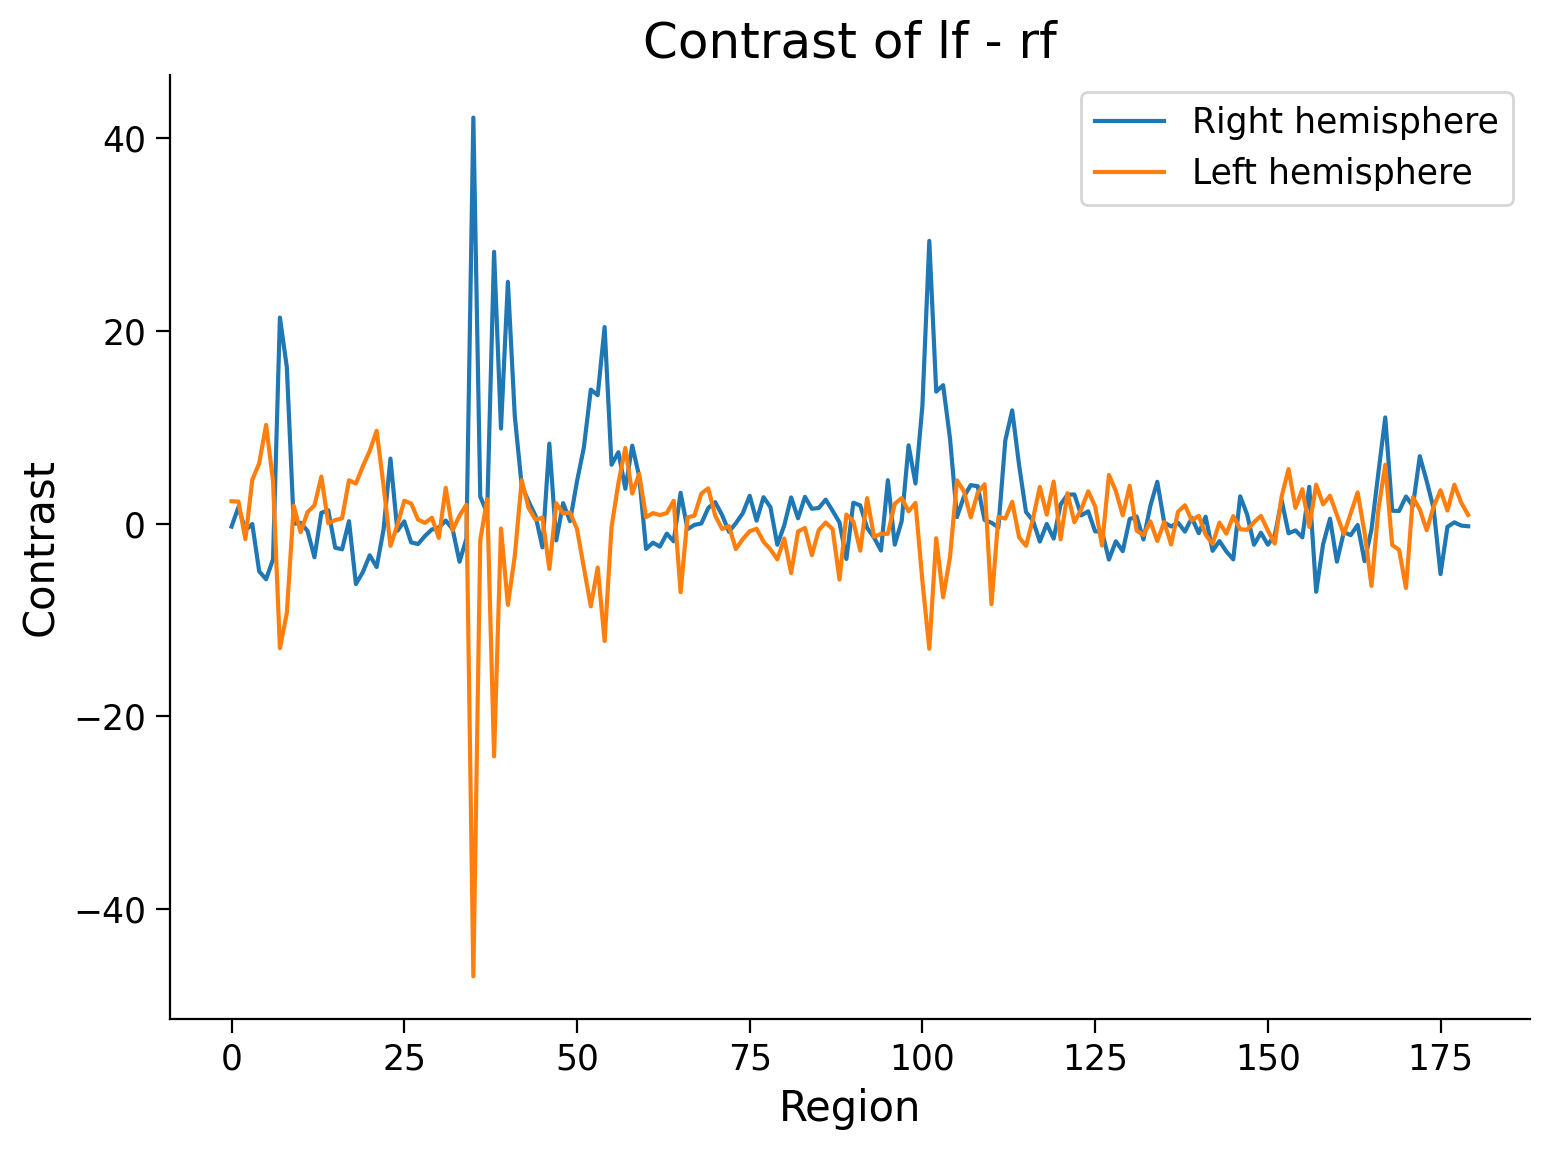

In [23]:
hemi_contrasts = np.split(group_contrast, 2) # Divide the group vector into 180 ROIs per hemisphere [right, left], then plot as two lines.

plt.figure()
for i, hemi_contrast in enumerate(hemi_contrasts):
  plt.plot(hemi_contrast, label=f"{HEMIS[i]} hemisphere")

plt.title(f"Contrast of {conditions[0]} - {conditions[1]}")
plt.xlabel("Region")
plt.ylabel('Contrast')
plt.legend()
plt.show()

<details>
<summary><strong>Reflection: 🔎 Line plot of ROI-wise contrast (lf − rf)</strong></summary>

- **Blue = right hemisphere, orange = left hemisphere.**  
- **Positive peaks in blue** = right hemisphere regions more active for left-foot movement (expected contralateral control).  
- **Negative dips in orange** = left hemisphere regions more active for right-foot movement, when right-foot activation dominates in the left hemisphere, the contrast drops sharply into negative values.  
- **Which regions are these?** - Large fluctuations align with **motor/somatosensory areas** The sharp spikes occur in the primary motor and sensory cortex (the central strip of the brain that controls body movement and touch). In the brain's body map (*the motor homunculus*), the representation of the foot and toes is located at the top-medial wall of this strip.
Minor fluctuations in other regions reflect general task demands (such as processing visual cues or sustaining attention).
</details>

Plot the regional values on the surface of one hemisphere:

In [24]:
fsaverage = datasets.fetch_surf_fsaverage()
surf_contrast = group_contrast[atlas["labels_R"]]
plotting.view_surf(fsaverage['infl_right'], surf_contrast, vmax=15)

Map parcel values to the labels_R surface indices and visualize on the inflated right hemisphere.
- Colors reflect the contrast value in each parcel.

<details>
<summary><strong>Reflection: 🔎 Surface projection (right hemisphere)</strong></summary>

- **Colors = contrast values (lf-rf) per parcel.**  
- **Bright yellow / white**: Strong positive activation. This confirms that the right hemisphere activates heavily during movement of the contralateral left foot (stronger for left-hand movement, so <code>lf − rf > 0</code>). **Dark red / black**: Regions not actively engaged by foot movement.
- **Anatomical interpretation (Foot vs. Hand)**: Notice on the *Left view* (inside surface): the bright activation cluster is located at the very top and medial wall of the cortex. This top-medial ridge corresponds to the foot and leg, whereas the hand area would be positioned lower down on the outer lateral surface.
- Because we mapped values from the **Glasser atlas**: each parcel is assigned a single uniform mean value, creating parcel boundaries instead of a continuous smooth gradient.  
</details>

## Characterize values by functional network

Average the contrast values within parcels belonging to each network and plot:

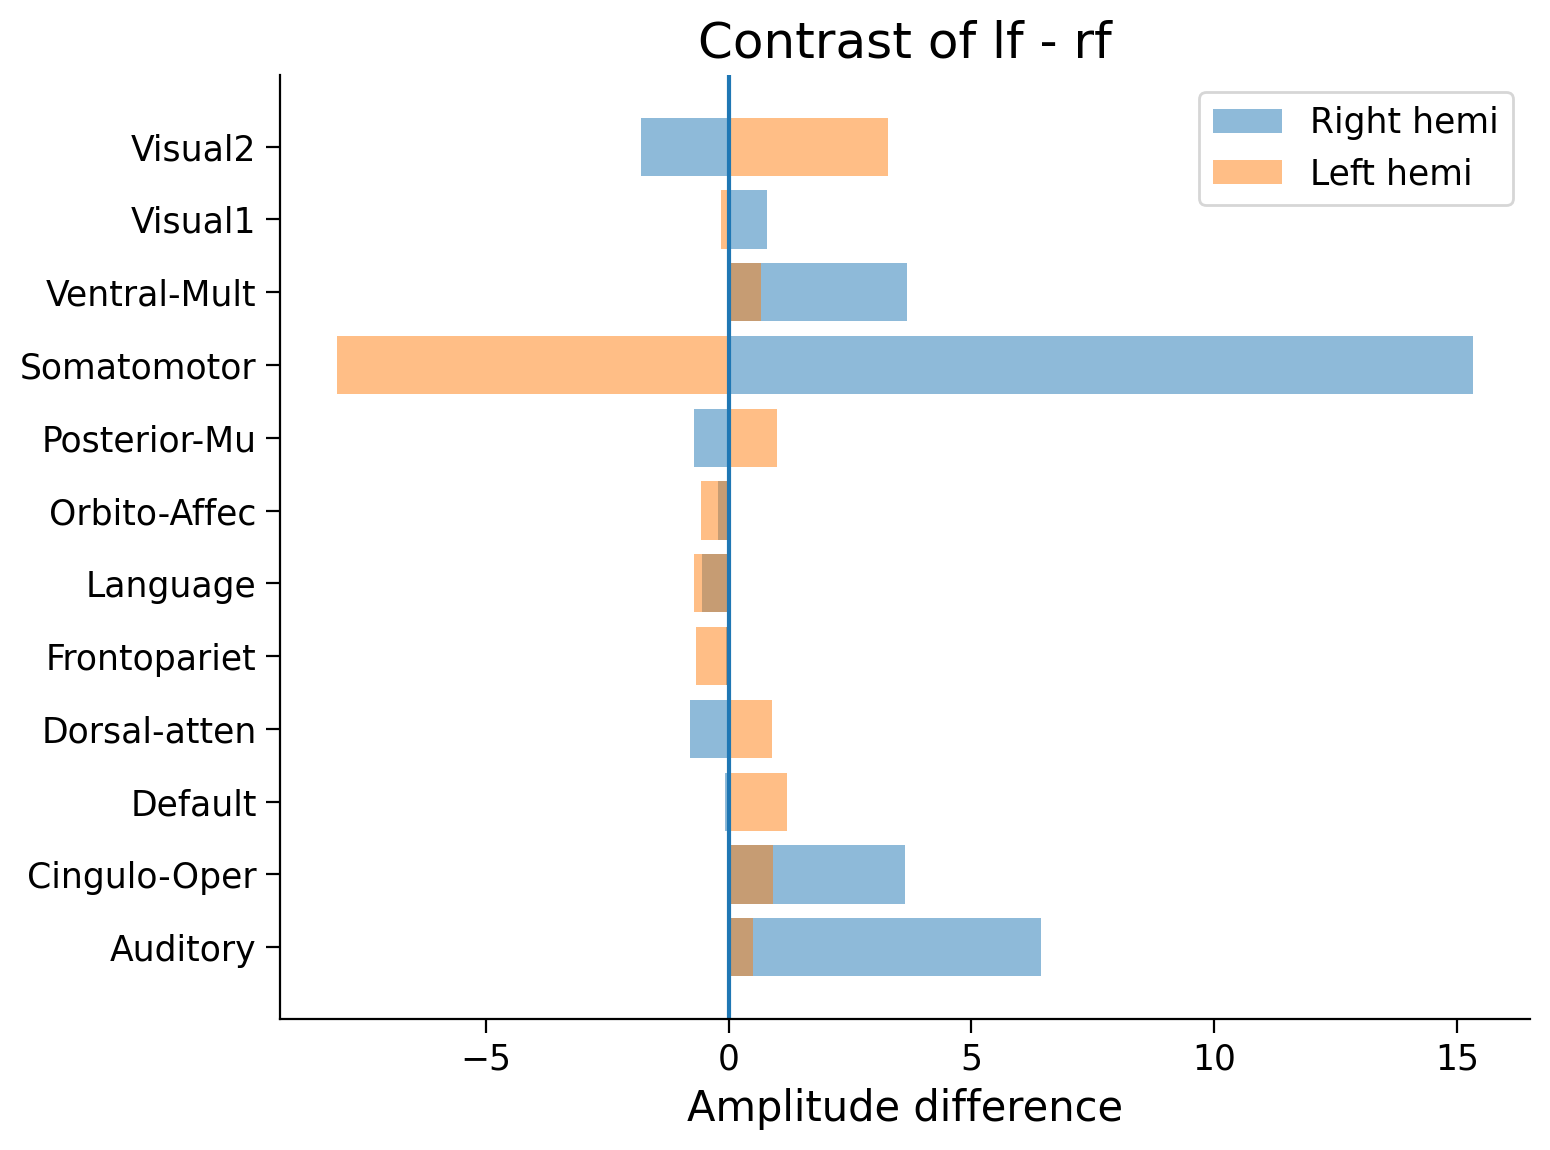

In [25]:
# Get unique network labels
network_names = np.unique(region_info["network"])

hemi_networks = np.split(region_info["network"], 2)
hemi_contrasts = np.split(group_contrast, 2)

plt.figure()
# Get and plot mean contrast value per network, by hemisphere
for hemi, hemi_network, hemi_contrast in zip(HEMIS, hemi_networks, hemi_contrasts):
  network_vals = []
  for network in network_names:
    network_vals.append(hemi_contrast[hemi_network == network].mean())
  plt.barh(network_names, network_vals, alpha=.5, label=f"{hemi} hemi")

plt.axvline(0)
plt.xlabel("Amplitude difference")
plt.title(f"Contrast of {conditions[0]} - {conditions[1]}")
plt.legend()
plt.show()

For each network (Somatomotor, Visual, Default, etc.), compute the mean contrast value across its parcels.
- Plot as bar graphs, separately for left and right hemisphere.

<details>
<summary><strong>Reflection: 🔎 Network-level bar plot</strong></summary>

- **Dimensionality reduction**: Instead of looking at 360 individual parcels, we group and average them into 12 large-scale functional networks.
- Largest differences are in the **Somatomotor network**:  
  - Right hemisphere shows **positive contrast** (left-foot movement).  
  - Left hemisphere shows **negative contrast** (right-foot movement).  
- Higher-order cognitive networks (**Visual / Language / DMN networks**) show small effects (due to task cues or ancillary processes).  
- **Key takeaway**: Cognitive subtraction (lf-rf) successfully filters out whole-brain background noise and cleanly isolates the target functional network.
</details>

# 🧭 Find functional differences between fear and neutral stimulus

## Load EMOTION timeseries per run

Load each subject's data for a specific task, separately for each run:

In [84]:
timeseries_task = []
for subject in subjects:
  timeseries_task.append(load_timeseries(subject, "EMOTION",
                                         dir=os.path.join(HCP_DIR, "hcp_task"),
                                         concat=False))

Output: list of matrices 360 × T per run.

## Compute average condition profiles

We extract average responses for fear and neutral separately:

In [86]:
task = "EMOTION"
conditions = ["fear", "neut"]

contrast = []
for subject in subjects:

  # Get the average signal in each region for each condition
  evs = [load_evs(subject, task, cond, dir=os.path.join(HCP_DIR, "hcp_task")) for cond in conditions]
  avgs = [selective_average(timeseries_task[subject], ev) for ev in evs]

  # Store signal from both regions
  contrast.append(avgs)

group_contrast = np.mean(contrast, axis=0)

In [87]:
group_contrast.shape

(2, 360)

- group_contrast[0] = mean profile for fear across all subjects.
- group_contrast[1] = mean profile for neutral.

## Line plot of condition responses

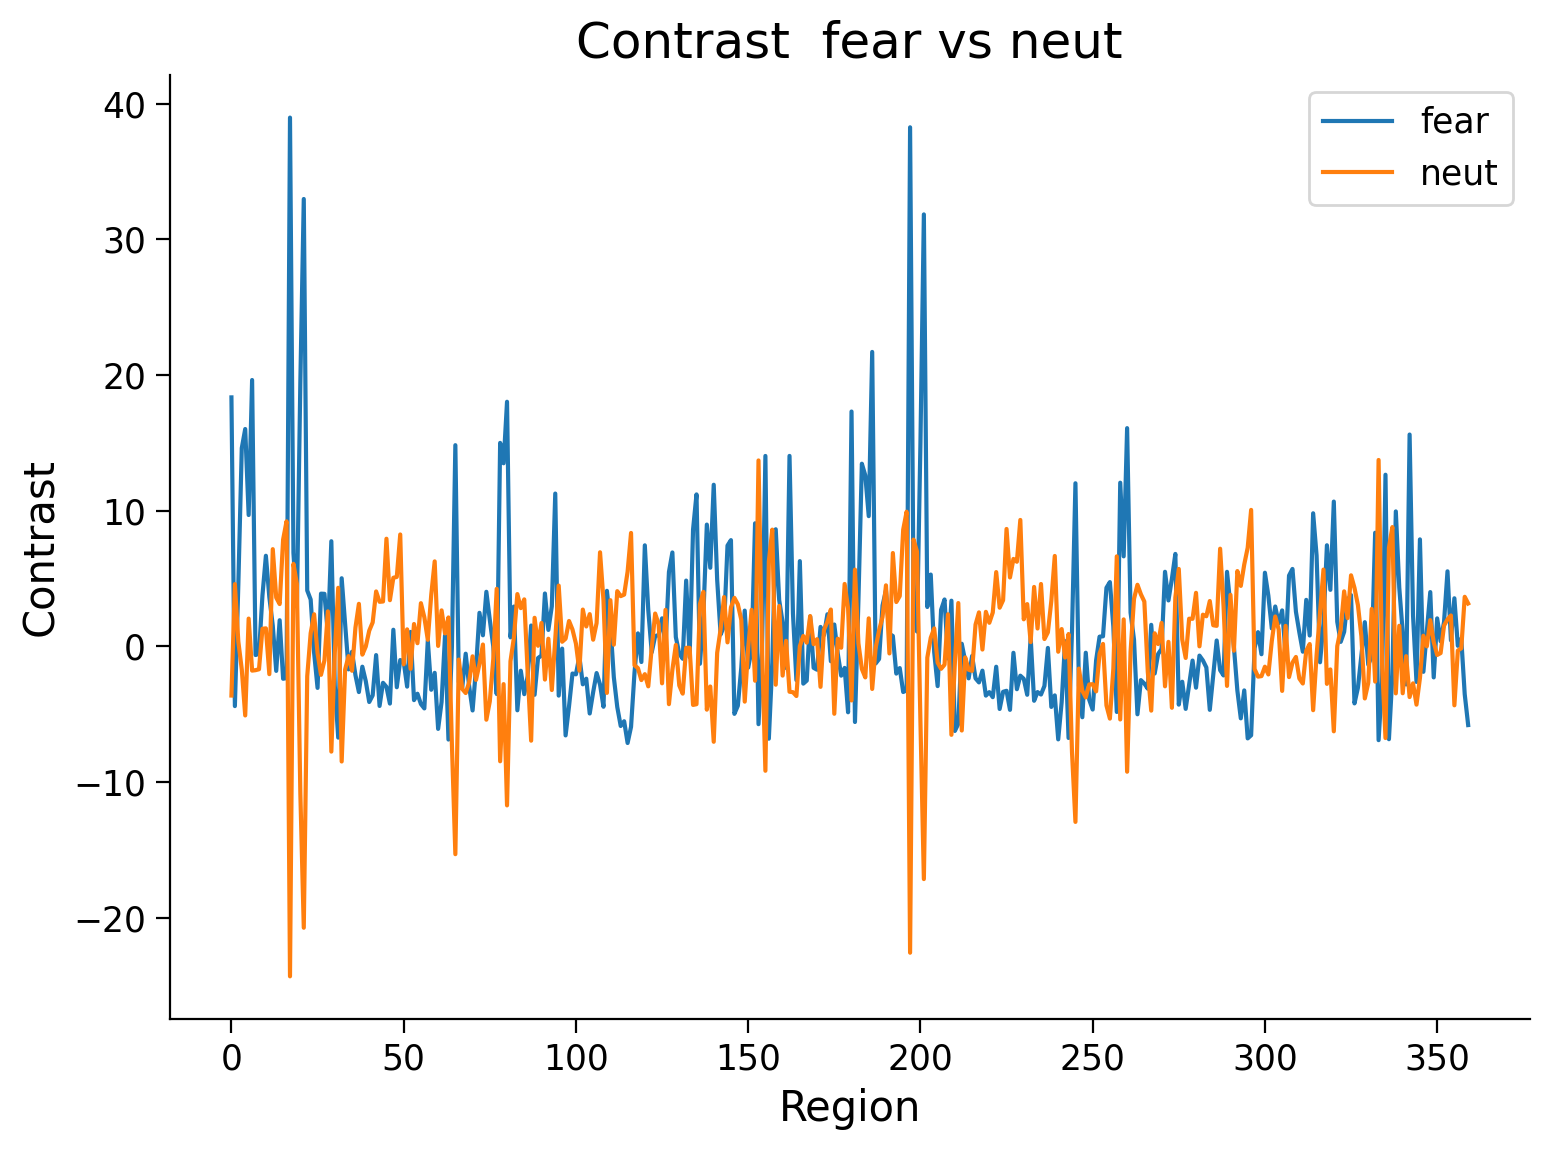

In [88]:
plt.figure()
for i, cond_contrast in enumerate(group_contrast):
  plt.plot(cond_contrast, label=f"{conditions[i]}")

plt.title(f"Contrast  {conditions[0]} vs {conditions[1]}")
plt.xlabel("Region")
plt.ylabel('Contrast')
plt.legend()
plt.show()

- Two curves:  Blue = fear, Orange = neutral.
- They show per-ROI activation strength for each condition (not a subtraction yet).
- Peaks = regions with higher responses in fear or neutral.

<details>
<summary><strong>Reflection: 🔎 Line plot of condition responses (fear vs. neut)</strong></summary>

**Key Observations**:
1. Bilateral Symmetry: Notice the striking twin spikes around Region ~20 (right hemisphere) and Region ~200 (left hemisphere). Unlike the motor task which was strongly one-sided (lateralized), face/emotion perception engages the ventral visual stream in both hemispheres.
2. Massive Category Selectivity:
In these specific visual parcels, the fear condition evokes strong positive activation, while the neut (shapes) condition drops deep into negative values. These parcels correspond to the Fusiform Face Complex (FFC) and inferotemporal visual areas, which are specialized for recognizing faces compared to simple shapes.
3. Spatial Specificity:
Most other cortical parcels (frontal, motor, parietal) stay close to zero, showing that this task selectively modulates high-level visual and affective networks.
</details>

## Identify most different ROIs

We compute the absolute difference between conditions for each ROI:

In [89]:
contrast_dict ={}
for i in range(group_contrast.shape[1]):
  region_name = region_info['name'][i]
  diff = np.abs(group_contrast[0][i] - group_contrast[1][i])
  contrast_dict[region_name] = diff

- Sort ROIs by difference to find regions that discriminate most strongly.
- Typically top hits = visual-temporal areas (e.g., FFC, PIT, LO2).

In [118]:
sorted(contrast_dict.items(), key = lambda item: item[1], reverse =True)[:15]

[('R_FFC', np.float64(63.307041121976596)),
 ('L_FFC', np.float64(60.85087753784342)),
 ('R_PIT', np.float64(53.724442120454114)),
 ('L_PIT', np.float64(49.00081073473386)),
 ('R_LO2', np.float64(30.26129871858639)),
 ('R_47m', np.float64(30.152449052211765)),
 ('R_IFSp', np.float64(29.755655331957968)),
 ('L_IFSp', np.float64(25.32863595913102)),
 ('L_47m', np.float64(24.965314914053373)),
 ('L_V8', np.float64(24.84622423456267)),
 ('R_IFJa', np.float64(23.471535571951897)),
 ('R_V4t', np.float64(23.20955013757424)),
 ('R_V1', np.float64(21.979808779619052)),
 ('R_V8', np.float64(21.423659024410682)),
 ('L_V1', np.float64(21.300717911241136))]

Interpretation: these regions are especially sensitive to emotional face stimuli.

## Aggregate by functional networks

We compute average activation per network for each condition:

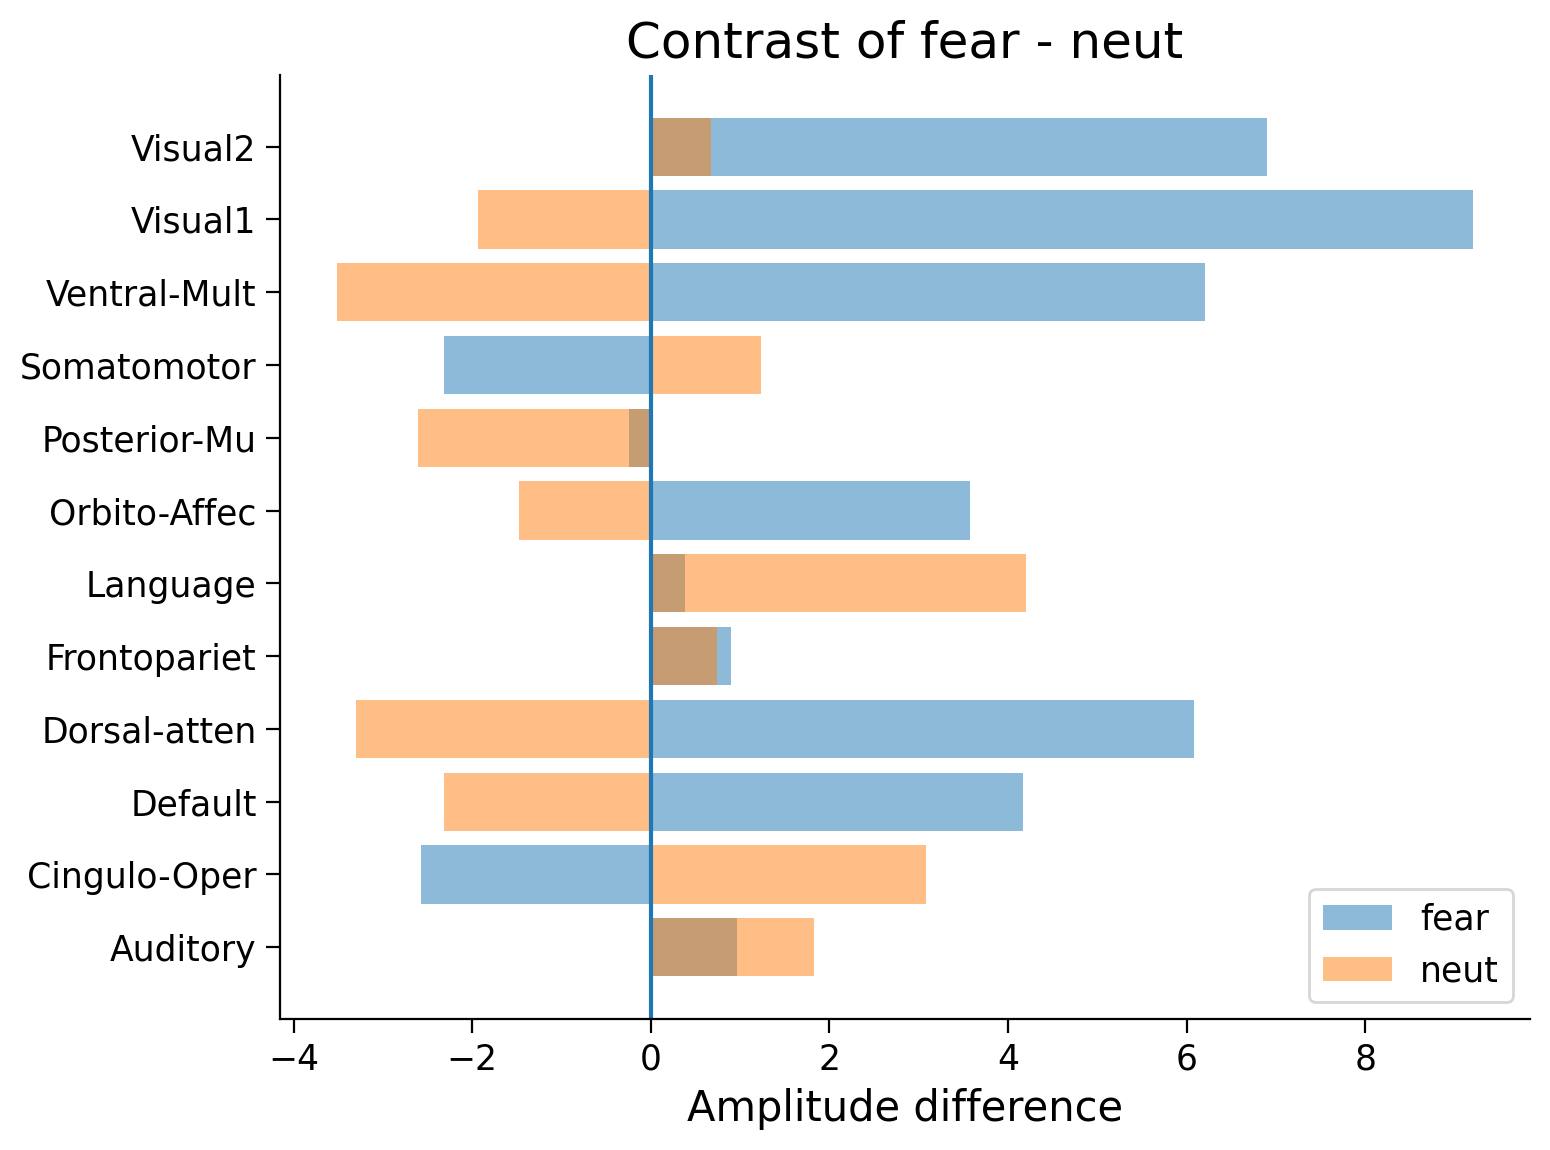

In [92]:
# Get unique network labels
network_names = np.unique(region_info["network"])

plt.figure()
# Get and plot mean contrast value per network, by condition
for i, contrast in enumerate(group_contrast):
  network_vals = []
  for network in network_names:
    network_vals.append(contrast[region_info["network"] == network].mean())
  plt.barh(network_names, network_vals, alpha=.5, label=f"{conditions[i]}")

plt.axvline(0)
plt.xlabel("Amplitude difference")
plt.title(f"Contrast of {conditions[0]} - {conditions[1]}")
plt.legend()
plt.show()

- Horizontal bars show mean activity across networks.
- Visual and attention-related networks show largest differences, while Language/DMN remain closer to zero.

<details>
<summary><strong>Reflection: 🔎 What the plots show</strong></summary>

- **Line plots**: Blue (fear) vs orange (neutral). Where blue > orange, fear condition evokes stronger response. Peaks usually appear in occipital/temporal ROIs (FFA / PIT / FFC).  
- **Network-level bars**:
    - Visual and dorsal-attention networks show strong differences; other networks (e.g., Auditory, Language) have weaker or near-zero effects.
    - Notice that for fear, the Default Mode Network is positive, while for neut it is negative. In the Glasser parcellation, sub-regions of the DMN support social cognition and mentalizing—evaluating another human's emotional state engages these social hubs.
</details>

### Putting It Together: What the Results Mean

- **Resting state.** Reveals intrinsic network architecture (strong within-network FC, known anti-correlations).
- **Motor task.** Clear contralateral somatomotor activation (left movement → right hemisphere; right movement → left hemisphere).
- **Emotion task.** Stronger responses in visual/ventral temporal regions to faces, with fear vs neutral differences concentrated in face/visual pathways and attention systems.
- **Networks & atlas.** Parcel-level findings are interpretable via network labels (Somatomotor, Visual, DMN, etc.); myelin values provide biological context but are optional here.

### Next Steps

- Move from raw activation/contrasts to features: parcel means, functional connectivity (task or rest), network summaries, graph measures.
- Use these features for machine learning (e.g., classification, regression) to study disorders or behavioral phenotypes; evaluate importance of features and interpretability.